In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

plt.style.use("ggplot")
plt.rcParams["font.family"] = "Tahoma"  # ensure Thai glyphs render

data_path = "../data/plate_lower/labels.csv"
df = pd.read_csv(data_path)

print(f"rows: {len(df):,}")
df.head()

rows: 10,208


,filename,label,source,transactionDate,plate,province_code,province_description,brand_description,colors_code,colors_description,vehicleClass
0,8000_0_lower.jpg,ราชบุรี,8000,2024-07-05 14:00:23.865,กง8989,TH-70,ราชบุรี,HONDA,VCOLOR0009,เทา,1.0
1,8000_1_lower.jpg,กรุงเทพมหานคร,8000,2024-07-05 14:00:25.967,5กณ2033,TH-10,กรุงเทพมหานคร,TOYOTA,VCOLOR0007,ดำ,1.0
2,8000_2_lower.jpg,กรุงเทพมหานคร,8000,2024-07-05 14:00:32.549,2ฒห6707,TH-10,กรุงเทพมหานคร,TOYOTA,VCOLOR0008,ขาว,1.0
3,8000_3_lower.jpg,กรุงเทพมหานคร,8000,2024-07-05 14:00:45.088,4ขฎ7688,TH-10,กรุงเทพมหานคร,ไม่พบข้อมูล,VCOLOR0009,เทา,1.0
4,8000_4_lower.jpg,ชลบุรี,8000,2024-07-05 14:00:46.100,ขล2431,TH-20,ชลบุรี,MAZDA,VCOLOR0008,ขาว,1.0


,count
ก,3798
ข,2631
ค,329
ฆ,429
ง,361
จ,376
ฉ,321
ช,416
ซ,0
ฌ,391


,count
0,2632
1,5265
2,5429
3,5501
4,4674
5,4791
6,4444
7,4237
8,4623
9,4824


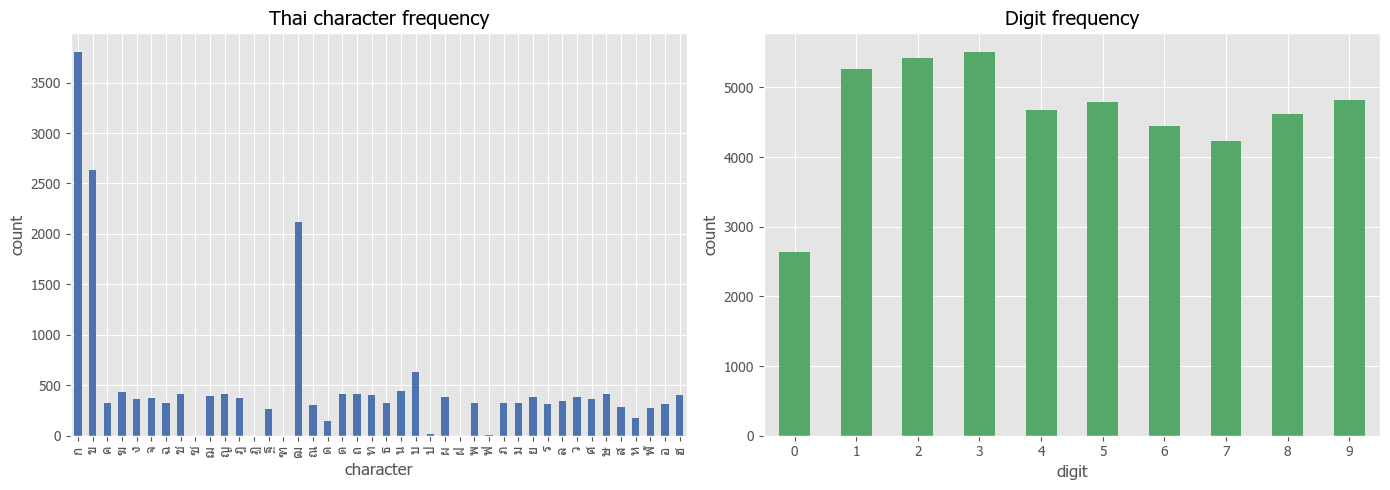

In [8]:
# Count Thai letters (top line) and digits (bottom line) across all plates
plates = (
    df["plate"]
    .fillna("")
    .astype(str)
    .str.replace("ไม่พบข้อมูล", "", regex=False)
)

thai_letters = [
    "ก","ข","ค","ฆ","ง","จ","ฉ","ช","ซ","ฌ","ญ","ฎ","ฏ","ฐ","ฑ","ฒ","ณ","ด","ต","ถ","ท","ธ","น","บ","ป","ผ","ฝ","พ","ฟ","ภ","ม","ย","ร","ล","ว","ศ","ษ","ส","ห","ฬ","อ","ฮ",
]
digit_labels = list("0123456789")

thai_pattern = re.compile(r"[\u0E00-\u0E7F]")
digit_pattern = re.compile(r"\d")

thai_counter = Counter()
digit_counter = Counter()

for plate in plates:
    thai_counter.update(thai_pattern.findall(plate))
    digit_counter.update(digit_pattern.findall(plate))

thai_series = (
    pd.Series(thai_counter, dtype=int)
    .reindex(thai_letters)
    .fillna(0)
    .astype(int)
)
digit_series = (
    pd.Series(digit_counter, dtype=int)
    .reindex(digit_labels)
    .fillna(0)
    .astype(int)
)

display(thai_series.to_frame(name="count"))
display(digit_series.to_frame(name="count"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
thai_series.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Thai character frequency")
axes[0].set_xlabel("character")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=90)

digit_series.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Digit frequency")
axes[1].set_xlabel("digit")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

,count
province_description,
กรุงเทพมหานคร,8791
กระบี่,1
กาญจนบุรี,3
กาฬสินธุ์,9
กำแพงเพชร,17
...,...
อุดรธานี,17
อุตรดิตถ์,3
อุทัยธานี,11


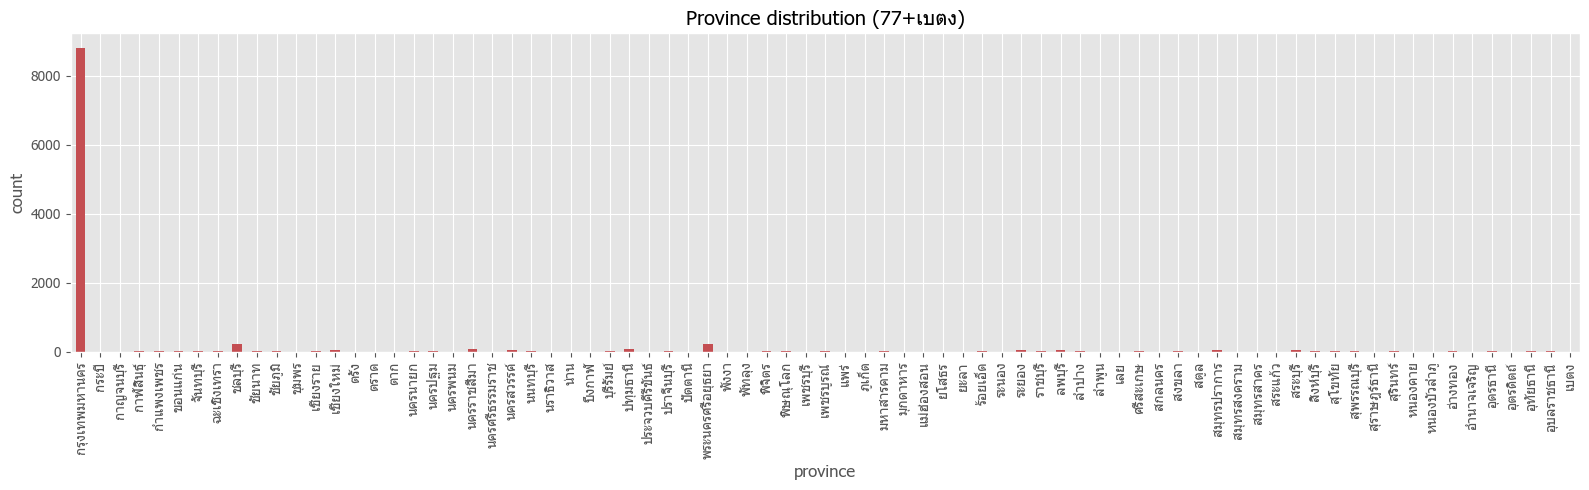

In [9]:
full_provinces = [
    "กรุงเทพมหานคร","กระบี่","กาญจนบุรี","กาฬสินธุ์","กำแพงเพชร","ขอนแก่น","จันทบุรี","ฉะเชิงเทรา","ชลบุรี","ชัยนาท","ชัยภูมิ","ชุมพร","เชียงราย","เชียงใหม่","ตรัง","ตราด","ตาก","นครนายก","นครปฐม","นครพนม","นครราชสีมา","นครศรีธรรมราช","นครสวรรค์","นนทบุรี","นราธิวาส","น่าน","บึงกาฬ","บุรีรัมย์","ปทุมธานี","ประจวบคีรีขันธ์","ปราจีนบุรี","ปัตตานี","พระนครศรีอยุธยา","พังงา","พัทลุง","พิจิตร","พิษณุโลก","เพชรบุรี","เพชรบูรณ์","แพร่","ภูเก็ต","มหาสารคาม","มุกดาหาร","แม่ฮ่องสอน","ยโสธร","ยะลา","ร้อยเอ็ด","ระนอง","ระยอง","ราชบุรี","ลพบุรี","ลำปาง","ลำพูน","เลย","ศรีสะเกษ","สกลนคร","สงขลา","สตูล","สมุทรปราการ","สมุทรสงคราม","สมุทรสาคร","สระแก้ว","สระบุรี","สิงห์บุรี","สุโขทัย","สุพรรณบุรี","สุราษฎร์ธานี","สุรินทร์","หนองคาย","หนองบัวลำภู","อ่างทอง","อำนาจเจริญ","อุดรธานี","อุตรดิตถ์","อุทัยธานี","อุบลราชธานี","เบตง",
]

province_col = "province_description" if "province_description" in df.columns else "label"
province_counts_raw = (
    df[province_col]
    .replace("ไม่พบข้อมูล", pd.NA)
    .dropna()
    .astype(str)
    .str.strip()
)

province_counts = (
    province_counts_raw.value_counts()
    .reindex(full_provinces)
    .fillna(0)
    .astype(int)
)

display(province_counts.to_frame(name="count"))

plt.figure(figsize=(16, 5))
province_counts.plot(kind="bar", color="#C44E52")
plt.title("Province distribution (77+เบตง)")
plt.xlabel("province")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()